# Evaluation & Model Comparison

Structured evaluation for the **final sweep-best model** (notebook 5), aligned with `proposal.md` §7:

- **Quantitative**: train / val / **test** loss & perplexity, generalization gaps
- **Qualitative**: prompt suite + Shakespearean `CHARACTER:` → dialogue format checks
- **Comparison**: baseline (notebook 3) vs sweep-best vs final run (local JSON + W&B)

## Prerequisites

1. `2. Preprocessing.ipynb` → `data/artifacts/{train_ids,val_ids,test_ids,char_vocab}.pt/json`
2. `5. Model Training.ipynb` → `data/artifacts/model/gpt_best.pt`, `experiment.json`
3. Optional: copy notebook-3 artifacts before notebook 5 overwrote them:
   - `gpt_baseline.pt` and `baseline_experiment.json` in `data/artifacts/model/`
4. `pip install wandb` and `wandb login` (optional, for W&B tables)

In [1]:
from pathlib import Path
import json
import math
import re
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import wandb
except ImportError:
    wandb = None

plt.style.use("seaborn-v0_8-darkgrid")

cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Could not locate 'data' from cwd: {cwd}")

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = DATA_DIR / "artifacts"
CHECKPOINT_DIR = ARTIFACTS_DIR / "model"

FINAL_CKPT = CHECKPOINT_DIR / "gpt_best.pt"
FINAL_EXPERIMENT = CHECKPOINT_DIR / "experiment.json"
BASELINE_CKPT = CHECKPOINT_DIR / "gpt_baseline.pt"
BASELINE_EXPERIMENT = CHECKPOINT_DIR / "baseline_experiment.json"
SWEEP_META_PATH = ARTIFACTS_DIR / "sweep_best_config.json"

EVAL_CONFIG = {
    "block_size": 128,
    "batch_size": 32,
    "eval_batches": 100,
    "use_amp": True,
    "seed": 42,
    "wandb_project": "genre-story-generator",
    "wandb_entity": None,
    "wandb_group": "evaluation",
    "wandb_job_type": "evaluation",
    "run_name": "eval-final-vs-baseline",
    "sweep_id": "kbmij8of",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Load Data

Includes the held-out **test** split (not evaluated during training in notebook 5).

In [2]:
train_ids_path = ARTIFACTS_DIR / "train_ids.pt"
val_ids_path = ARTIFACTS_DIR / "val_ids.pt"
test_ids_path = ARTIFACTS_DIR / "test_ids.pt"
vocab_path = ARTIFACTS_DIR / "char_vocab.json"

for p in (train_ids_path, val_ids_path, test_ids_path, vocab_path):
    assert p.exists(), f"Missing {p}. Run preprocessing notebook first."

train_ids = torch.load(train_ids_path, weights_only=True)
val_ids = torch.load(val_ids_path, weights_only=True)
test_ids = torch.load(test_ids_path, weights_only=True)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_payload = json.load(f)

vocab_size = vocab_payload["vocab_size"]
stoi = vocab_payload["stoi"]
itos = {int(k): v for k, v in vocab_payload["itos"].items()}


def encode(text: str) -> list[int]:
    return [stoi[ch] for ch in text]


def decode(indices) -> str:
    return "".join(itos[int(i)] for i in indices)


SPLIT_DATA = {"train": train_ids, "val": val_ids, "test": test_ids}


def get_batch(
    split: str,
    batch_size: int,
    block_size: int,
    device: str = device,
):
    data = SPLIT_DATA[split]
    if len(data) <= block_size:
        raise ValueError(f"{split} split too short for block_size={block_size}")
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


print(
    f"train: {train_ids.shape} | val: {val_ids.shape} | "
    f"test: {test_ids.shape} | vocab: {vocab_size}"
)

train: torch.Size([1003836]) | val: torch.Size([55762]) | test: torch.Size([55796]) | vocab: 65


## Model Architecture

Decoder-only GPT (same family as notebooks 4–5).

In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer("mask", None, persistent=False)

    def _causal_mask(self, size: int, device: torch.device):
        if self.mask is None or self.mask.size(0) < size:
            self.mask = torch.tril(torch.ones(size, size, device=device)).view(1, 1, size, size)
        return self.mask[:, :, :size, :size]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.size()
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        def reshape_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape_heads(q), reshape_heads(k), reshape_heads(v)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = self._causal_mask(T, x.device)
        att = att.masked_fill(mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(y))


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff_mult: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff_mult * d_model),
            nn.GELU(),
            nn.Linear(d_ff_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, config: dict):
        super().__init__()
        d_model = config["d_model"]
        n_heads = config["n_heads"]
        n_layers = config["n_layers"]
        dropout = config["dropout"]
        block_size = config["block_size"]
        d_ff_mult = config.get("d_ff", 4)
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff_mult, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.size()
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block_size {self.block_size}")
        pos = torch.arange(0, T, device=idx.device, dtype=torch.long).unsqueeze(0)
        x = self.drop(self.token_embedding(idx) + self.pos_embedding(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: int = 0,
        top_p: float = 1.0,
    ):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size :]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-8)
            if top_k > 0:
                k = min(top_k, logits.size(-1))
                v, _ = torch.topk(logits, k, dim=-1)
                logits = logits.masked_fill(logits < v[:, [-1]], float("-inf"))
            if top_p < 1.0:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                remove = cum_probs - F.softmax(sorted_logits, dim=-1) >= top_p
                sorted_logits[remove] = float("-inf")
                logits = sorted_logits.scatter(1, sorted_idx, sorted_logits)
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, num_samples=1)], dim=1)
        return idx

## Load Checkpoint & Estimate Loss

In [4]:
def load_final_checkpoint(path: Path = FINAL_CKPT):
    assert path.exists(), f"Missing {path}. Run notebook 5 first."
    ckpt = torch.load(path, map_location=device, weights_only=False)

    if isinstance(ckpt, dict) and "model" in ckpt and "config" in ckpt:
        config = copy.deepcopy(ckpt["config"])
        state = ckpt["model"]
    else:
        raise ValueError(
            "Expected notebook-5 checkpoint format {model, config}. "
            "For notebook-3 weights use gpt_baseline.pt."
        )

    config["block_size"] = config.get("block_size", EVAL_CONFIG["block_size"])
    model = GPTLanguageModel(vocab_size=vocab_size, config=config).to(device)
    model.load_state_dict(state)
    model.eval()
    return model, config


@torch.no_grad()
def estimate_loss(
    model: nn.Module,
    splits: tuple[str, ...] = ("train", "val", "test"),
    num_batches: int | None = None,
):
    model.eval()
    num_batches = num_batches or EVAL_CONFIG["eval_batches"]
    block_size = EVAL_CONFIG["block_size"]
    batch_size = EVAL_CONFIG["batch_size"]
    out = {}

    for split in splits:
        losses = []
        for _ in range(num_batches):
            x, y = get_batch(split, batch_size, block_size, device)
            with torch.amp.autocast(device_type=device, enabled=EVAL_CONFIG["use_amp"]):
                _, loss = model(x, y)
            losses.append(loss.item())
        avg = float(np.mean(losses))
        out[split] = {"loss": avg, "ppl": math.exp(avg)}

    return out


final_model, final_config = load_final_checkpoint()
n_params = sum(p.numel() for p in final_model.parameters())
print(f"Loaded final model | params: {n_params:,}")
print(
    f"  n_layers={final_config['n_layers']} d_model={final_config['d_model']} "
    f"n_heads={final_config['n_heads']} dropout={final_config['dropout']}"
)

Loaded final model | params: 15,895,040
  n_layers=5 d_model=512 n_heads=8 dropout=0.15540136469775573


## Quantitative Evaluation

Proposal §7: validation loss/perplexity and train–val gap (memorization on TinyShakespeare). We also report **test** perplexity (held out during training).

,split,loss,perplexity
0,train,1.1261,3.0836
1,val,1.4117,4.1028
2,test,1.5805,4.8572


,metric,gap
0,val - train,0.2856
1,test - train,0.4544
2,test - val,0.1688


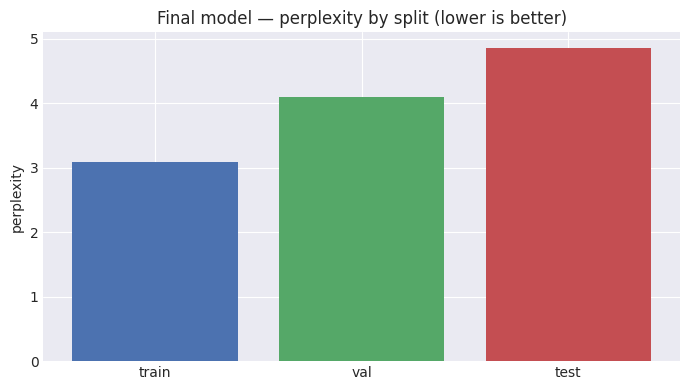

Note: test perplexity notably above val — possible mild overfitting to val selection.


In [5]:
metrics = estimate_loss(final_model, splits=("train", "val", "test"))

rows = []
for split, m in metrics.items():
    rows.append({"split": split, "loss": m["loss"], "perplexity": m["ppl"]})

metrics_df = pd.DataFrame(rows)
display(metrics_df.round(4))

train_loss = metrics["train"]["loss"]
val_loss = metrics["val"]["loss"]
test_loss = metrics["test"]["loss"]

gaps = pd.DataFrame(
    [
        {"metric": "val - train", "gap": val_loss - train_loss},
        {"metric": "test - train", "gap": test_loss - train_loss},
        {"metric": "test - val", "gap": test_loss - val_loss},
    ]
)
display(gaps.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metrics_df["split"], metrics_df["perplexity"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("perplexity")
ax.set_title("Final model — perplexity by split (lower is better)")
plt.tight_layout()
plt.show()

if test_loss > val_loss * 1.05:
    print("Note: test perplexity notably above val — possible mild overfitting to val selection.")
elif train_loss < val_loss * 0.85:
    print("Note: large train/val gap — model may be memorizing (expected on TinyShakespeare at scale).")

## Model Comparison

Baseline (notebook 3) vs sweep-best vs final run. Baseline metrics come from `baseline_experiment.json` if you saved it before notebook 5.

Optional: save notebook-3 experiment as /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/baseline_experiment.json


,model,source,n_layers,width,n_heads,params,train_loss,val_loss,test_loss,val_ppl,test_ppl,val_minus_train
0,Final (sweep-best + cosine),live eval + experiment.json,5,512,8,15895040.0,1.126089,1.411671,1.580455,4.102807,4.857164,0.285582
1,Sweep best (trial),sweep kbmij8of,5,512,8,NaN,NaN,1.439192,NaN,4.217288,NaN,NaN


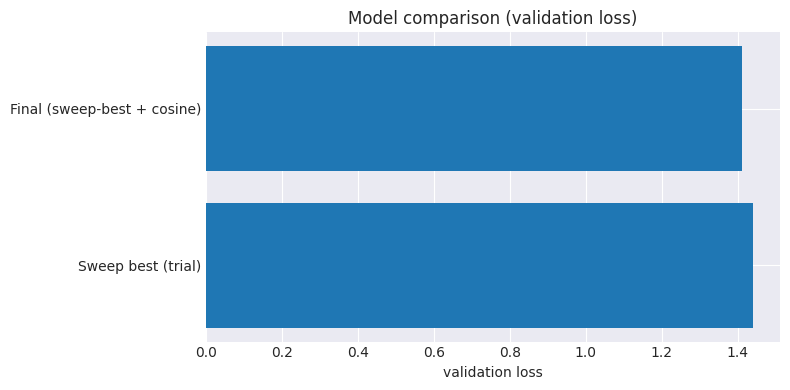

In [6]:
def _read_json(path: Path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


comparison_rows = []

final_exp = _read_json(FINAL_EXPERIMENT)
comparison_rows.append(
    {
        "model": "Final (sweep-best + cosine)",
        "source": "live eval + experiment.json",
        "n_layers": final_config.get("n_layers"),
        "width": final_config.get("d_model"),
        "n_heads": final_config.get("n_heads"),
        "params": n_params,
        "train_loss": metrics["train"]["loss"],
        "val_loss": metrics["val"]["loss"],
        "test_loss": metrics["test"]["loss"],
        "val_ppl": metrics["val"]["ppl"],
        "test_ppl": metrics["test"]["ppl"],
        "val_minus_train": metrics["val"]["loss"] - metrics["train"]["loss"],
    }
)

baseline_exp = _read_json(BASELINE_EXPERIMENT)
if baseline_exp:
    cfg = baseline_exp.get("config", {})
    comparison_rows.append(
        {
            "model": "Baseline (notebook 3)",
            "source": "baseline_experiment.json",
            "n_layers": cfg.get("n_layers"),
            "width": cfg.get("n_embd"),
            "n_heads": cfg.get("n_heads"),
            "params": baseline_exp.get("total_params"),
            "train_loss": baseline_exp.get("final_train_loss"),
            "val_loss": baseline_exp.get("best_val_loss") or baseline_exp.get("final_val_loss"),
            "test_loss": None,
            "val_ppl": baseline_exp.get("best_val_ppl"),
            "test_ppl": None,
            "val_minus_train": (
                (baseline_exp.get("final_val_loss") or baseline_exp.get("best_val_loss", 0))
                - baseline_exp.get("final_train_loss", 0)
            ),
        }
    )
else:
    print(f"Optional: save notebook-3 experiment as {BASELINE_EXPERIMENT}")

sweep_meta = _read_json(SWEEP_META_PATH)
if sweep_meta:
    hp = sweep_meta.get("hyperparameters", {})
    sweep_val = sweep_meta.get("sweep_best_val_loss")
    comparison_rows.append(
        {
            "model": "Sweep best (trial)",
            "source": f"sweep {sweep_meta.get('sweep_id', '?')}",
            "n_layers": hp.get("n_layers"),
            "width": hp.get("d_model"),
            "n_heads": hp.get("n_heads"),
            "params": None,
            "train_loss": None,
            "val_loss": sweep_val,
            "test_loss": None,
            "val_ppl": math.exp(sweep_val) if sweep_val is not None else None,
            "test_ppl": None,
            "val_minus_train": None,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

plot_df = comparison_df.dropna(subset=["val_loss"])
if len(plot_df) > 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(plot_df["model"], plot_df["val_loss"])
    ax.set_xlabel("validation loss")
    ax.set_title("Model comparison (validation loss)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## W&B Sweep Leaderboard

In [7]:
SWEEP_METRIC = "val/loss"
SWEEP_PARAMS = [
    "learning_rate",
    "n_layers",
    "d_model",
    "n_heads",
    "dropout",
    "weight_decay",
    "warmup_steps",
]


def fetch_sweep_runs(sweep_id: str) -> pd.DataFrame:
    if wandb is None:
        raise ImportError("wandb not installed")

    api = wandb.Api()
    entity = EVAL_CONFIG.get("wandb_entity") or api.default_entity
    project = EVAL_CONFIG["wandb_project"]
    sweep = api.sweep(f"{entity}/{project}/{sweep_id}")

    rows = []
    for run in sweep.runs:
        if run.summary.get(SWEEP_METRIC) is None:
            continue
        row = {
            "run_name": run.name,
            "run_id": run.id,
            "state": run.state,
            SWEEP_METRIC: float(run.summary[SWEEP_METRIC]),
            "val/perplexity": float(
                run.summary.get("val/perplexity") or math.exp(run.summary[SWEEP_METRIC])
            ),
            "model/parameters": run.summary.get("model/parameters"),
        }
        for p in SWEEP_PARAMS:
            row[p] = run.config.get(p)
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(SWEEP_METRIC).reset_index(drop=True)


if wandb is not None:
    try:
        sweep_df = fetch_sweep_runs(EVAL_CONFIG["sweep_id"])
        display(sweep_df.head(10))
        if len(sweep_df):
            print(
                f"Top trial: {sweep_df.iloc[0]['run_name']} | "
                f"{SWEEP_METRIC}={sweep_df.iloc[0][SWEEP_METRIC]:.4f}"
            )
    except Exception as exc:
        print(f"W&B sweep fetch skipped: {exc}")
else:
    print("wandb not available — skipping sweep leaderboard")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/gwr4170/.netrc.


,run_name,run_id,state,val/loss,val/perplexity,model/parameters,learning_rate,n_layers,d_model,n_heads,dropout,weight_decay,warmup_steps
0,earthy-sweep-6,zhocttbr,finished,1.439192,4.217288,15895040,0.001259,5,512,8,0.155401,0.20,200
1,daily-sweep-10,knqe4o7v,finished,1.471029,4.353713,12742656,0.001861,4,512,4,0.111189,0.05,200
2,worldly-sweep-7,1d3ur7a9,finished,1.538610,4.658112,12742656,0.000531,4,512,8,0.217492,0.20,200
3,magic-sweep-4,ubwju3kj,finished,1.570498,4.809044,7197696,0.003025,4,384,4,0.216535,0.10,200
4,absurd-sweep-5,hjrvfewx,finished,1.574724,4.829407,7197696,0.000766,4,384,8,0.232884,0.20,200
5,good-sweep-9,hqhz5w16,finished,1.689140,5.414822,15895040,0.003831,5,512,8,0.144232,0.10,200
6,legendary-sweep-8,hbuwbbal,finished,1.716356,5.564214,8972160,0.000199,5,384,8,0.111979,0.20,200
7,radiant-sweep-2,aes03di9,finished,1.789323,5.985400,19047424,0.000147,6,512,4,0.196954,0.20,50
8,fast-sweep-3,kkq9ns40,finished,1.840742,6.301214,1222912,0.001570,6,128,4,0.238762,0.10,200
9,worldly-sweep-1,knw6wxw8,finished,2.462419,11.733159,10746624,0.007864,6,384,8,0.268954,0.10,50


Top trial: earthy-sweep-6 | val/loss=1.4392


## Qualitative Evaluation

Proposal §7: check whether generations follow `CHARACTER_NAME:` → dialogue structure (see notebook 1).

In [8]:
SPEAKER_LINE = re.compile(r"^[A-Z][A-Z ]+:$")
SPEAKER_INLINE = re.compile(r"^([A-Z][A-Z ]+):")
TURN_PATTERN = re.compile(
    r"^([A-Z][A-Z ]+):\n(.*?)(?=\n[A-Z][A-Z ]+:|\Z)",
    re.MULTILINE | re.DOTALL,
)

PROMPTS = [
    "ROMEO:",
    "JULIET:",
    "KING:",
    "LADY CAPULET:",
    "First Citizen:",
]

SAMPLING_PROFILES = {
    "greedy": {"temperature": 1.0, "top_k": 0, "top_p": 1.0},
    "balanced": {"temperature": 0.8, "top_k": 40, "top_p": 0.9},
}


def score_shakespeare_format(text: str) -> dict:
    lines = [ln for ln in text.splitlines() if ln.strip()]
    n_lines = max(len(lines), 1)
    speaker_lines = sum(1 for ln in lines if SPEAKER_LINE.match(ln.strip()))
    inline_speakers = len(SPEAKER_INLINE.findall(text))
    turns = TURN_PATTERN.findall(text)

    return {
        "num_lines": len(lines),
        "speaker_label_lines": speaker_lines,
        "speaker_label_rate": speaker_lines / n_lines,
        "inline_speaker_markers": inline_speakers,
        "dialogue_turns_parsed": len(turns),
        "has_act_marker": bool(re.search(r"^ACT [IVX]+", text, re.MULTILINE)),
        "has_scene_marker": bool(re.search(r"^SCENE [IVX]+", text, re.MULTILINE)),
    }


@torch.no_grad()
def generate_sample(model, prompt: str, max_new_tokens: int = 400, **kwargs) -> str:
    ctx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out_ids = model.generate(ctx, max_new_tokens=max_new_tokens, **kwargs)
    return decode(out_ids[0].tolist())


qual_rows = []
generated = {}

for profile_name, samp in SAMPLING_PROFILES.items():
    for prompt in PROMPTS:
        text = generate_sample(final_model, prompt, **samp)
        key = f"{profile_name} | {prompt}"
        generated[key] = text
        fmt = score_shakespeare_format(text)
        qual_rows.append(
            {
                "profile": profile_name,
                "prompt": prompt,
                "chars": len(text),
                **fmt,
            }
        )

qual_df = pd.DataFrame(qual_rows)
display(qual_df)

for key, text in generated.items():
    print("=" * 72)
    print(key)
    print(text[:600])
    if len(text) > 600:
        print("...")

,profile,prompt,chars,num_lines,speaker_label_lines,speaker_label_rate,inline_speaker_markers,dialogue_turns_parsed,has_act_marker,has_scene_marker
0,greedy,ROMEO:,406,9,1,0.111111,1,1,False,False
1,greedy,JULIET:,407,17,4,0.235294,1,4,False,False
2,greedy,KING:,405,14,5,0.357143,1,5,False,False
3,greedy,LADY CAPULET:,413,9,1,0.111111,1,1,False,False
4,greedy,First Citizen:,414,13,3,0.230769,0,3,False,False
5,balanced,ROMEO:,406,15,7,0.466667,1,7,False,False
6,balanced,JULIET:,407,13,4,0.307692,1,4,False,False
7,balanced,KING:,405,15,6,0.400000,1,6,False,False
8,balanced,LADY CAPULET:,413,12,4,0.333333,1,4,False,False
9,balanced,First Citizen:,414,13,2,0.153846,0,2,False,False


greedy | ROMEO:
ROMEO:
Thou art a greater, wouldst thou art wonder to
pass his finger! He changes, what new, is got
slanders me there was in law'd, I will beat him flowed of follower.
I bound at the rack or years I see what he speaks,
Thou mayst bear the greatest night-censury,
Which for his tender privilege never wrong'd
And hand his face was to the steel;
Or can his will soon back'd against the palace in subtle's chi
greedy | JULIET:
JULIET:
My lord;
He is dead less for it that to read to the joice
With me worse of honour gentle Caesar saint.

LADY ANNE:
Be revenged, daughter, and thou bless of God,
Return, as the heavens lies of thy safety plague
Of one double any dlen in peace I
Cannot forget? What do here?

Clown:
Do so, he?

VAUGHAN:
I do, and there for Rome!

CAPULET:
Not accords me here?

Second Messenger:
She that sooners will
greedy | KING:
KING:
Bear me waste; killing Hie from him.

WARWICK:
The king at a sleeping-horse: which could I loved him?

KING HENRY VI:
By this daili

## Save Report & Log to W&B

In [9]:
eval_report = {
    "final_config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in final_config.items()},
    "metrics": metrics,
    "generalization_gaps": gaps.to_dict(orient="records"),
    "comparison_table": comparison_df.to_dict(orient="records"),
    "qualitative_scores": qual_df.to_dict(orient="records"),
    "generated_samples": {k: v[:3000] for k, v in generated.items()},
    "n_params": n_params,
}

report_path = CHECKPOINT_DIR / "evaluation_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(eval_report, f, indent=2)

print(f"Wrote {report_path}")

if wandb is not None:
    run = wandb.init(
        project=EVAL_CONFIG["wandb_project"],
        entity=EVAL_CONFIG.get("wandb_entity"),
        group=EVAL_CONFIG["wandb_group"],
        job_type=EVAL_CONFIG["wandb_job_type"],
        name=EVAL_CONFIG["run_name"],
        config=EVAL_CONFIG,
    )

    for split, m in metrics.items():
        wandb.log({f"eval/{split}_loss": m["loss"], f"eval/{split}_ppl": m["ppl"]})

    wandb.log({"eval/val_minus_train": val_loss - train_loss})
    wandb.log({"eval/test_minus_train": test_loss - train_loss})

    wandb.log(
        {
            "eval/metrics_table": wandb.Table(dataframe=metrics_df),
            "eval/comparison_table": wandb.Table(dataframe=comparison_df),
            "eval/format_scores": wandb.Table(dataframe=qual_df),
            "eval/generations": wandb.Table(
                columns=["setting", "text"],
                data=[[k, v[:2000]] for k, v in generated.items()],
            ),
        }
    )

    run.summary.update(
        {
            "test_loss": test_loss,
            "test_perplexity": metrics["test"]["ppl"],
            "val_loss": val_loss,
            "best_final_val_from_training": final_exp.get("best_val_loss") if final_exp else None,
        }
    )
    run.finish()
    print("Logged evaluation run to W&B")
else:
    print("wandb not installed — skipped W&B logging")

wandb: Currently logged in as: utki007 (utki007-northwestern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Wrote /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/evaluation_report.json


eval/test_loss,▁
eval/test_minus_train,▁
eval/test_ppl,▁
eval/train_loss,▁
eval/train_ppl,▁
eval/val_loss,▁
eval/val_minus_train,▁
eval/val_ppl,▁
best_final_val_from_training,1.40341
eval/test_loss,1.58045
eval/test_minus_train,0.45437


Logged evaluation run to W&B


## Summary

| Criterion (proposal §7) | What we measured |
|-------------------------|------------------|
| Quantitative | Train / val / **test** loss & perplexity |
| Generalization | `val - train`, `test - train` gaps |
| Qualitative | Fixed prompts + `CHARACTER:` line / turn structure |
| Comparison | Baseline JSON, sweep metadata, final live eval |

**Interpretation (TinyShakespeare):** A large final model often shows low train loss with higher val/test — expected memorization pressure on ~1MB of text.

**Next notebook:** `7. Inference & Interactive Generation.ipynb` — load `gpt_best.pt` / W&B artifact and demo temperature / top-k / top-p interactively (proposal §8).